# CdV system in python for LCEs and FTLEs
- implement rhs of CdV
- Use that and the trajectories form fortran to calculate
    - LCEs (t->infty)
    - FTLEs

In [1]:
import numpy as np
import cdv_utils
import matplotlib.pyplot as plt
import importlib

importlib.reload(cdv_utils)

<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [ ]:
from cdv_utils import (load_d, build_df, compute_eof,
                       plot_scatter, fit_hmm, compute_ftle_vectorized,
                       analyze_regime_escape_times, reconstruct_logs)

In [3]:
import math
params = [0.95, -0.76095, 0.1, 1.25, 0.2, 0.5]


def cdv(u, t):

    x1, x2, x3, x4, x5, x6 = u
    x1star, x4star, C, beta, gamma, b = params

    def alpha_m(m, b):
        return (8.*math.sqrt(2.)/math.pi)*(m*m/(4*m*m-1))*((b*b + m*m - 1)/(b*b+m*m))

    def beta_m(m, b):
        return beta*b*b/(b*b+m*m)

    def gamma_m(m, b):
        return gamma*(4*m*m*m/(4*m*m-1))*(math.sqrt(2)*b/(math.pi*(b*b + m*m)))

    def gamma_m_tld(m, b):
        return gamma*(4*m/(4*m*m-1))*(math.sqrt(2)*b/math.pi)

    def delta(m, b):
        return (64.*math.sqrt(2.)/(15.*math.pi))*((b*b - m*m+1)/(b*b+m*m))

    # epsilon = 16.*math.sqrt(2)/(5*math.pi)
    epsilon = 1.44050610585137

    x1dot = gamma_m_tld(1, b)*x3 - C*(x1 - x1star)
    x4dot = gamma_m_tld(2, b)*x6 - C*(x4 - x4star) + epsilon*(x2*x6 - x3*x5)

    x2dot = -(alpha_m(1, b)*x1 - beta_m(1, b))*x3 - C*x2 - delta(1, b)*x4*x6
    x5dot = -(alpha_m(2, b)*x1 - beta_m(2, b))*x6 - C*x5 - delta(2, b)*x4*x3

    x3dot = (alpha_m(1, b)*x1 - beta_m(1, b))*x2 - \
        gamma_m(1, b)*x1 - C*x3 + delta(1, b)*x4*x5
    x6dot = (alpha_m(2, b)*x1 - beta_m(2, b))*x5 - \
        gamma_m(2, b)*x4 - C*x6 + delta(2, b)*x4*x2

    return np.array([x1dot, x2dot, x3dot, x4dot, x5dot, x6dot])


def cdvjac(u, t):

    x1, x2, x3, x4, x5, x6 = u
    x1star, x4star, C, beta, gamma, b = params

    def alpha_m(m, b):
        return (8.*math.sqrt(2.)/math.pi)*(m*m/(4*m*m-1))*((b*b + m*m - 1)/(b*b+m*m))

    def beta_m(m, b):
        return beta*b*b/(b*b+m*m)

    def gamma_m(m, b):
        return gamma*(4*m*m*m/(4*m*m-1))*(math.sqrt(2)*b/(math.pi*(b*b + m*m)))

    def gamma_m_tld(m, b):
        return gamma*(4*m/(4*m*m-1))*(math.sqrt(2)*b/math.pi)

    def delta(m, b):
        return (64.*math.sqrt(2.)/(15.*math.pi))*((b*b - m*m+1)/(b*b+m*m))

    # epsilon = 16.*math.sqrt(2)/(5*math.pi)
    epsilon = 1.44050610585137

    dx1dot = np.array([-C, 0., gamma_m_tld(1, b), 0., 0., 0.])
    dx2dot = np.array([-alpha_m(1, b)*x3, -C, -alpha_m(1, b)
                      * x1 + beta_m(1, b), -delta(1, b)*x6, 0., -delta(1, b)*x4])
    dx3dot = np.array([alpha_m(1, b)*x2-gamma_m(1, b), alpha_m(1, b)
                      * x1 - beta_m(1, b), -C, delta(1, b)*x5, delta(1, b)*x4, 0.])
    dx4dot = np.array([0., epsilon*x6, -epsilon*x5, -C, -
                      epsilon*x3, gamma_m_tld(2, b)+epsilon*x2])
    dx5dot = np.array([-alpha_m(2, b)*x6, 0., -delta(2, b) *
                      x4, -delta(2, b)*x3, -C, -alpha_m(2, b)*x1 + beta_m(2, b)])
    dx6dot = np.array([alpha_m(2, b)*x5, delta(2, b)*x4, 0, -gamma_m(2,
                      b) + delta(2, b)*x2, alpha_m(2, b)*x1 - beta_m(2, b), -C])

    return np.array([dx1dot, dx2dot, dx3dot, dx4dot, dx5dot, dx6dot])

# Verfiy that the above is equivalent to fortran

In [8]:
dims = 6
sample_num = 200000
state_vector = load_d('./cdv_model/dataOro20.bin', dims, sample_num)

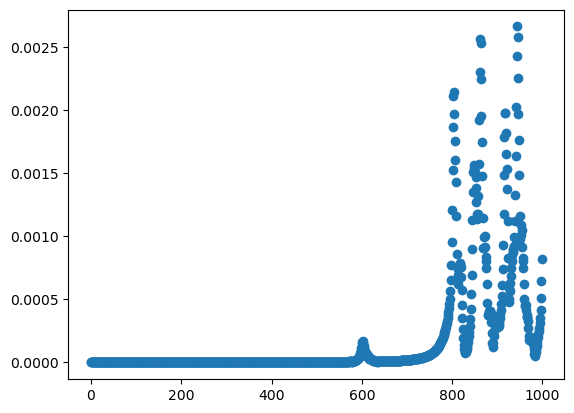

In [13]:
x0 = state_vector[0, :]
dt = 2e-4
sample_t = 1
t_f = 1000
x = np.zeros((int(t_f/sample_t), dims))
for j in range(int(t_f/dt)):
    if j % (sample_t/dt) == 0:
        # print(f'Sample {int(j // (sample_t / dt))} of {int(t_f/sample_t)}')
        x[int(j // (sample_t / dt)), :] = x0
    k1 = dt*cdv(x0, 0)

    k2 = dt * cdv(x0 + 0.5 * k1, 0)
    x0 = x0+k2

plt.plot(range(int(t_f/sample_t)), np.linalg.norm(
    x - state_vector[:int(t_f/sample_t), :], axis=1),
    'o')

# Functions for LE calculation

In [ ]:
import numpy as np
from scipy.linalg import qr


def rk45_step(func, t, y, dt):
    """
    Single fixed-step RK45 (Dormand–Prince) update.
    y_{n+1} = y_n + dt * sum_i B_i k_i, where k_i = f(t + C_i dt, y_n + dt sum_j A_{ij} k_j).
    """
    # Dormand-Prince coefficients
    A = np.array([
        [0, 0, 0, 0, 0, 0, 0],
        [1/5, 0, 0, 0, 0, 0, 0],
        [3/40, 9/40, 0, 0, 0, 0, 0],
        [44/45, -56/15, 32/9, 0, 0, 0, 0],
        [19372/6561, -25360/2187, 64448/6561, -212/729, 0, 0, 0],
        [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, 0, 0],
        [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0]
    ])
    C = np.array([0, 1/5, 3/10, 4/5, 8/9, 1, 1])
    B = np.array([35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0])

    k = np.zeros((7, y.size))
    for i in range(7):
        ti = t + C[i] * dt
        yi = y.copy()
        for j in range(i):
            yi += dt * A[i, j] * k[j]
        k[i] = func(ti, yi)
    return y + dt * np.tensordot(B, k, axes=(0, 0))


def integrate_state(eom, u0, dt, steps):
    """
    Integrate the system state x' = eom(x, t) from t=0.
    Returns times (shape (steps+1,)) and trajectory (steps+1, dim).
    """
    dim = u0.size
    traj = np.empty((steps + 1, dim))
    traj[0] = u0.copy()
    t = 0.0
    x = u0.copy()
    for n in range(1, steps + 1):
        x = rk45_step(lambda tt, yy: eom(yy, tt), t, x, dt)
        t += dt
        traj[n] = x
    times = np.linspace(0, steps * dt, steps + 1)
    return times, traj


def integrate_tangent(trajectory, jac, dt, transient=0, norm_interval=1):
    """
    Given trajectory x(t), integrate tangent M via dM/dt = J(x,t) M.
    QR normalization yields cumulative Lyapunov exponents over time.
    Returns normalization times and cumulative LEs.
    """
    steps_plus, dim = trajectory.shape[0], trajectory.shape[1]
    M_flat = np.eye(dim).ravel()
    log_stretches = []
    times = []
    t = 0.0

    for n in range(1, steps_plus):
        def rhs_M(tt, Mv):
            x = trajectory[n]
            return (jac(x, tt) @ Mv.reshape(dim, dim)).ravel()

        M_flat = rk45_step(rhs_M, t, M_flat, dt)
        t += dt

        if n > transient and n % norm_interval == 0:
            M = M_flat.reshape(dim, dim)
            Q, R = qr(M)
            log_stretches.append(np.log(np.abs(np.diag(R))))
            M_flat = Q.ravel()
            times.append(t)

    stretches = np.vstack(log_stretches)
    times = np.array(times)
    lyap_exponents = np.cumsum(stretches, axis=0) / times[:, None]
    return times, lyap_exponents


def ftle_from_jacobian_at_point(J, dt=1.0):
    """
    Instantaneous FTLEs at a single step: lambda_i = (1/dt) * ln(sigma_i).
    """
    sigma = np.linalg.svd(J, compute_uv=False)
    return np.log(np.clip(sigma, a_min=1e-16, a_max=None)) / dt


def compute_windowed_ftle(trajectory, jac, dt, window=1, n_jobs=-1):
    """
    Compute windowed FTLEs along a trajectory.

    For each index n >= window, form the product P = J(x_n)*J(x_{n-1})*...*J(x_{n-window+1}).
    Then lambda_i(n) = (1/(window*dt)) * ln(sigma_i(P)).

    Returns:
      times: shape (n_steps,), with times[n] = n*dt.
      ftles: shape (n_steps, dim), with NaN for n < window.
    """
    n_steps, dim = trajectory.shape
    ftles = np.full((n_steps, dim), np.nan)
    times = np.arange(n_steps) * dt

    # Precompute all Jacobians
    J_list = [jac(trajectory[n], times[n]) for n in range(n_steps)]

    for n in range(window - 1, n_steps):
        # compute product of window Jacobians
        P = np.eye(dim)
        for k in range(n - window + 1, n + 1):
            P = J_list[k] @ P
        ftles[n] = ftle_from_jacobian_at_point(P, dt=window * dt)

    return times, ftles


def compute_ky_dim(lyap_exponents):
    cum = np.cumsum(lyap_exponents)
    idx = np.argmax(cum < 0)
    return idx + cum[idx - 1] / abs(lyap_exponents[idx])

In [15]:
def lorenz_rhs(x, t, sigma=10, rho=28, beta=8/3):
    return np.array([sigma*(x[1]-x[0]), x[0]*(rho-x[2]) - x[1], x[0]*x[1] - beta*x[2]])


def lorenz_jac(x, t, sigma=10, rho=28, beta=8/3):
    return np.array([[-sigma, sigma, 0],
                     [rho - x[2], -1, -x[0]],
                     [x[1], x[0], -beta]])


x0 = np.array([1.5, -1.5, 20.])
t0 = 0.
dt = 1e-2

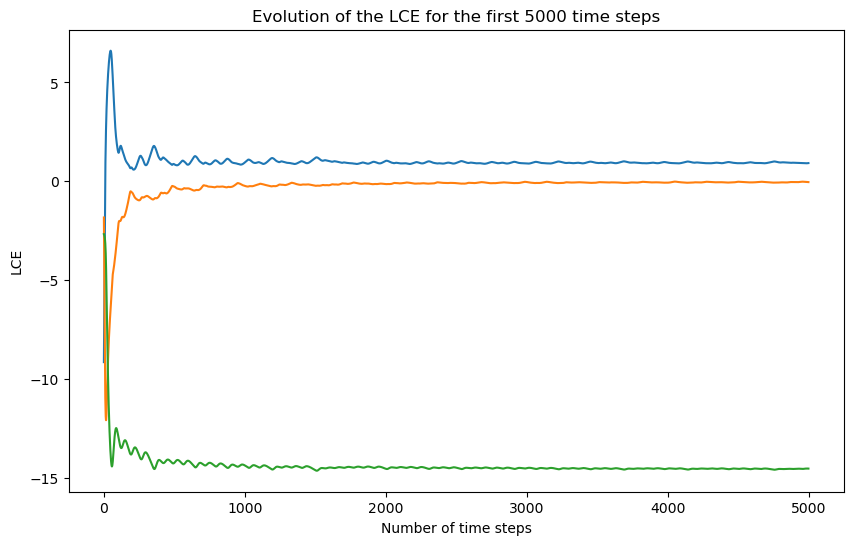

LCE: [ 9.10024194e-01 -2.70853454e-03 -1.45739819e+01]
KY dimension: 2.0622558521555563


In [6]:
# Xt, LEs = solve_lyapunov(lorenz_rhs, lorenz_jac, x0, dt, 10**5, 0, 1)
times, traj = integrate_state(lorenz_rhs, x0, dt=dt, steps=10**5)
stretch_times, LEs = integrate_tangent(traj, lorenz_jac, dt=dt,
                                       transient=0, norm_interval=1)
plt.figure(figsize=(10, 6))
plt.plot(LEs[:5000])
plt.xlabel("Number of time steps")
plt.ylabel("LCE")
plt.title("Evolution of the LCE for the first 5000 time steps")
plt.show()
print(f"LCE: {LEs[-1]}")  # Print the last LCE value
print(f"KY dimension: {compute_ky_dim(LEs[-1])}")

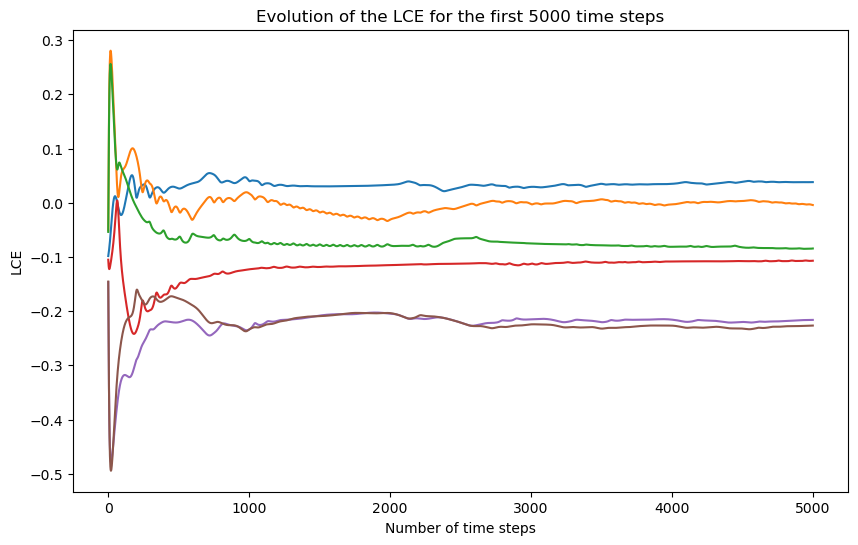

LCE: [ 2.27418300e-02 -8.44144415e-05 -8.10819622e-02 -1.02731644e-01
 -2.14358224e-01 -2.24485586e-01]
KY dimension: 2.2794384222066215


In [9]:
x0 = state_vector[0, :]
times, traj = integrate_state(cdv, x0, dt=.1, steps=10**5)
stretch_times, LEs = integrate_tangent(traj, cdvjac, dt=.1,
                                       transient=0, norm_interval=1)

plt.figure(figsize=(10, 6))
plt.plot(LEs[:5000])
plt.xlabel("Number of time steps")
plt.ylabel("LCE")
plt.title("Evolution of the LCE for the first 5000 time steps")
plt.show()
print(f"LCE: {LEs[-1]}")  # Print the last LCE value
print(f"KY dimension: {compute_ky_dim(LEs[-1])}")

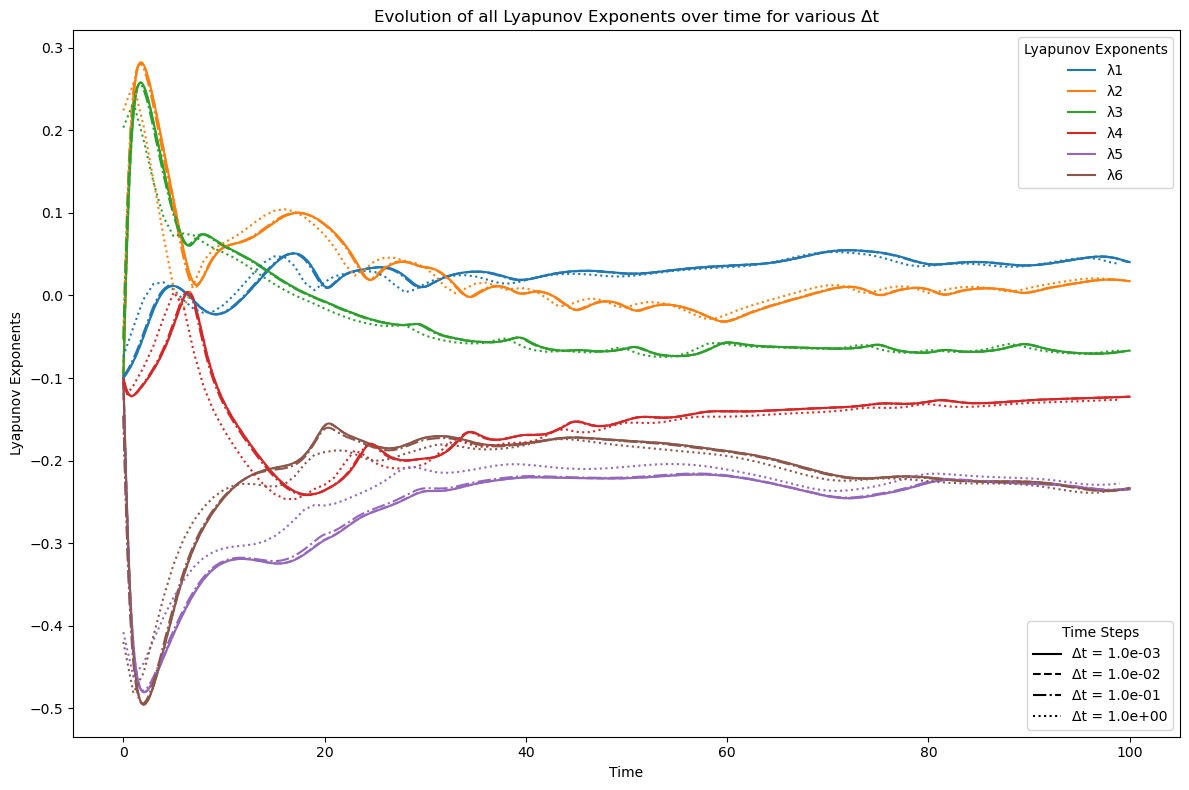

In [16]:
from matplotlib.lines import Line2D
x0 = state_vector[0, :]
dts = np.logspace(-3, 0, 4)
t_f = 100
t0 = 0.
linestyles = ['-', '--', '-.', ':']

# Dictionary to store histories for each dt
histories = {}
times_dict = {}

plt.figure(figsize=(12, 8))

for i, (dt, ls) in enumerate(zip(dts, linestyles)):
    # build and iterate the continuous dynamical system
    times, traj = integrate_state(cdv, x0, dt=dt, steps=int(t_f/dt))
    stretch_times, LEs = integrate_tangent(traj, cdvjac, dt=dt,
                                           transient=0, norm_interval=1)
    # Store history and times for this dt
    histories[dt] = LEs
    times = np.arange(len(LEs)) * dt
    times_dict[dt] = times

    # plot all 6 LCEs vs. time with different colors for each exponent
    for j in range(6):  # 6 Lyapunov exponents
        # Label for Lyapunov exponents (only for first dt)
        le_label = f'λ{j+1}' if i == 0 else ""
        plt.plot(times, LEs[:, j], linestyle=ls,
                 color=f'C{j}', label=le_label)

# Create custom legend entries for dt values
dt_legend_elements = [Line2D([0], [0], color='black', linestyle=ls,
                             label=f'Δt = {dt:.1e}')
                      for dt, ls in zip(dts, linestyles)]

# Create combined legend
le_legend = plt.legend(loc='upper right', title='Lyapunov Exponents')
dt_legend = plt.legend(handles=dt_legend_elements,
                       loc='lower right', title='Time Steps')
plt.gca().add_artist(le_legend)  # Add back the first legend

# final plot tweaks
plt.xlabel("Time")
plt.ylabel("Lyapunov Exponents")
plt.title("Evolution of all Lyapunov Exponents over time for various Δt")
plt.tight_layout()
plt.show()

**It seems like dt = 1e-1 is enough, so we use that to simulate asymptotics**

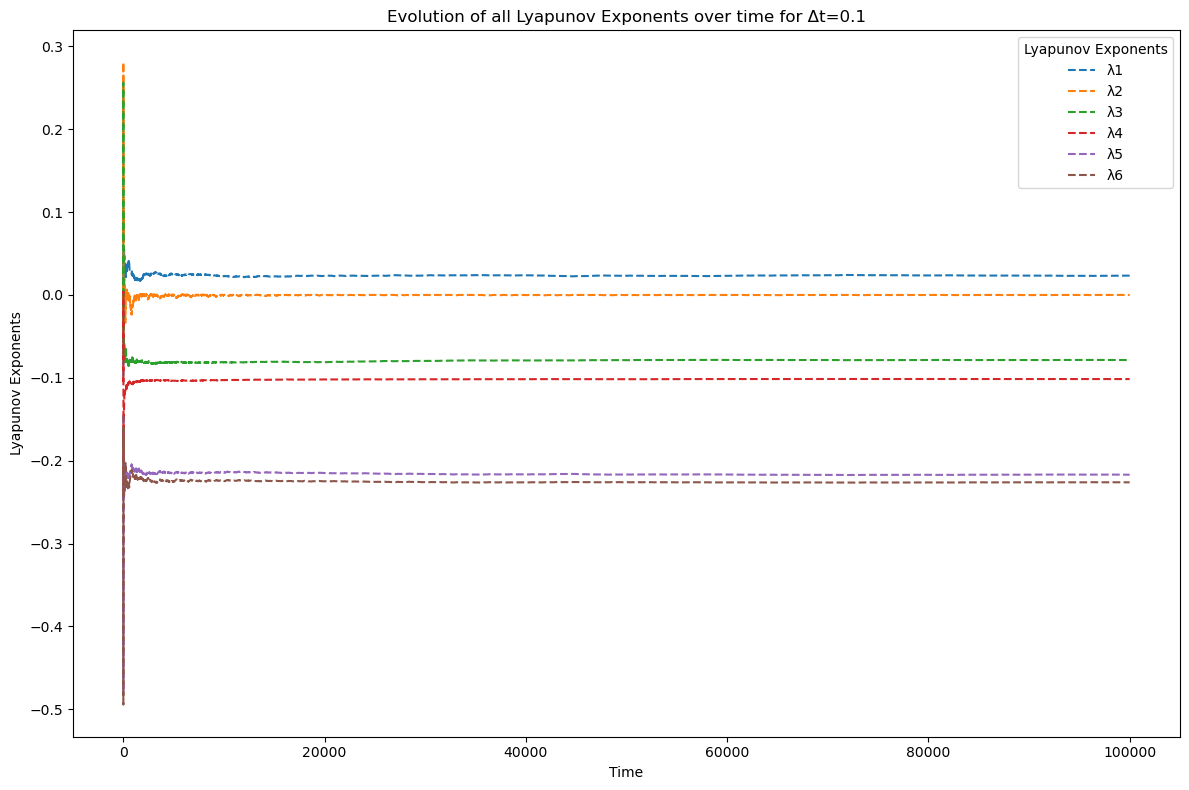

LCE: [ 2.32623812e-02 -3.54976163e-05 -7.86081797e-02 -1.01529610e-01
 -2.16949271e-01 -2.26139823e-01]
KY dimension: 2.29547667566067


In [ ]:
x0 = state_vector[0, :]
t_f = 1e5
t0 = 0.
dt = 1e-1
plt.figure(figsize=(12, 8))
times, traj = integrate_state(cdv, x0, dt=dt, steps=int(t_f/dt))
stretch_times, LEs = integrate_tangent(traj, cdvjac, dt=dt,
                                       transient=0, norm_interval=1)
times = np.arange(len(LEs)) * dt

for j in range(6):  # 6 Lyapunov exponents
    le_label = f'λ{j+1}'
    plt.plot(times, LEs[:, j], linestyle='--',
             color=f'C{j}', label=le_label)

plt.legend(loc='upper right', title='Lyapunov Exponents')

# final plot tweaks
plt.xlabel("Time")
plt.ylabel("Lyapunov Exponents")
plt.title("Evolution of all Lyapunov Exponents over time for Δt=0.1")
plt.tight_layout()
plt.show()

print(f"LCE: {LEs[-1]}")  # Print the last LCE value
print(f"KY dimension: {compute_ky_dim(LEs[-1])}")

In [ ]:


logs = reconstruct_logs(LEs, dt)

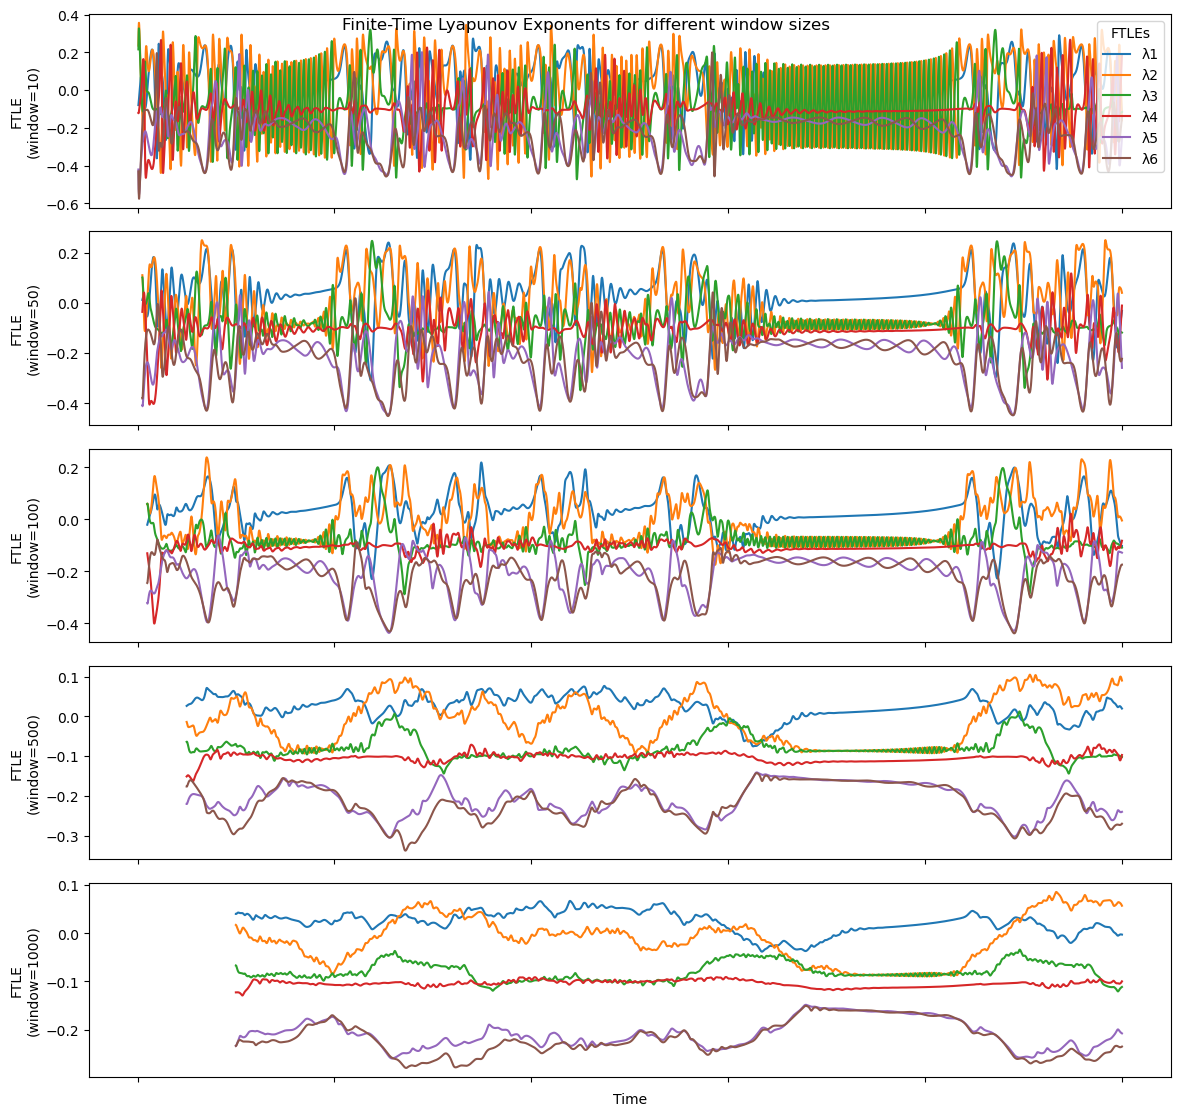

In [56]:
t_max = int(1e4)
window_sizes = [10, 50, 100, 500, 1000]
ftle_dict = {w: compute_ftle_vectorized(
    logs, dt, window=w) for w in window_sizes}
colors = [f'C{j}' for j in range(LEs.shape[0])]

fig, axes = plt.subplots(len(window_sizes), 1, figsize=(12, 12), sharex=True)

for idx, w in enumerate(window_sizes):
    ax = axes[idx]
    ftle = ftle_dict[w]
    for j in range(ftle.shape[1]):
        label = f'λ{j+1}' if idx == 0 else None
        ax.plot(times[:t_max], ftle[:t_max, j],
                color=colors[j], linestyle='-', label=label)
    ax.set_ylabel(f"FTLE\n(window={w})")
    if idx == 0:
        ax.legend(loc='upper right', title='FTLEs')
    if idx < len(window_sizes) - 1:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time")

fig.suptitle(
    "Finite-Time Lyapunov Exponents for different window sizes", y=0.92)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [68]:
df = build_df(Xt, dims)
results = compute_eof(df, n_modes=6)
scores_df = results['scores_df']
scores_df["ftle_1000_max"] = np.max(ftle_dict[1000], axis=1)

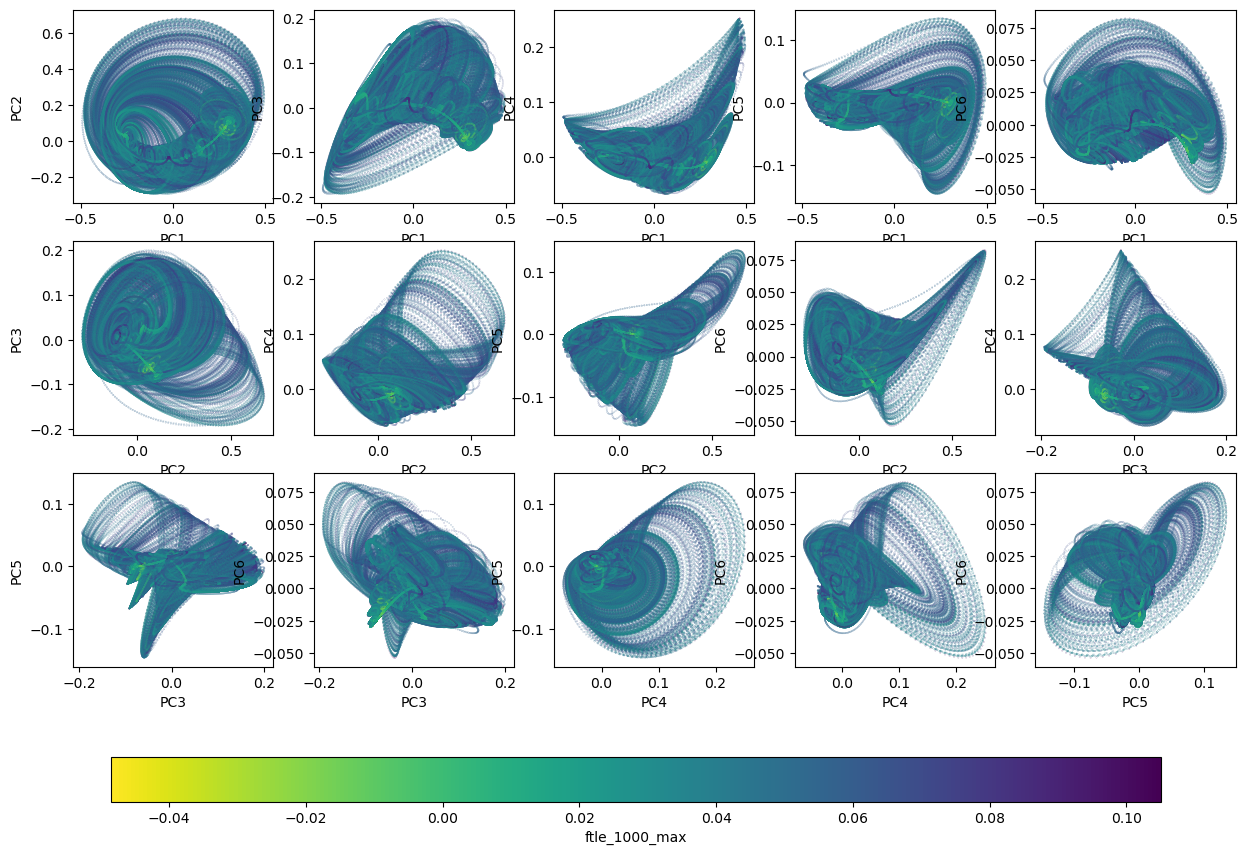

In [69]:
figs, axes = plot_scatter(scores_df, "ftle_1000_max")

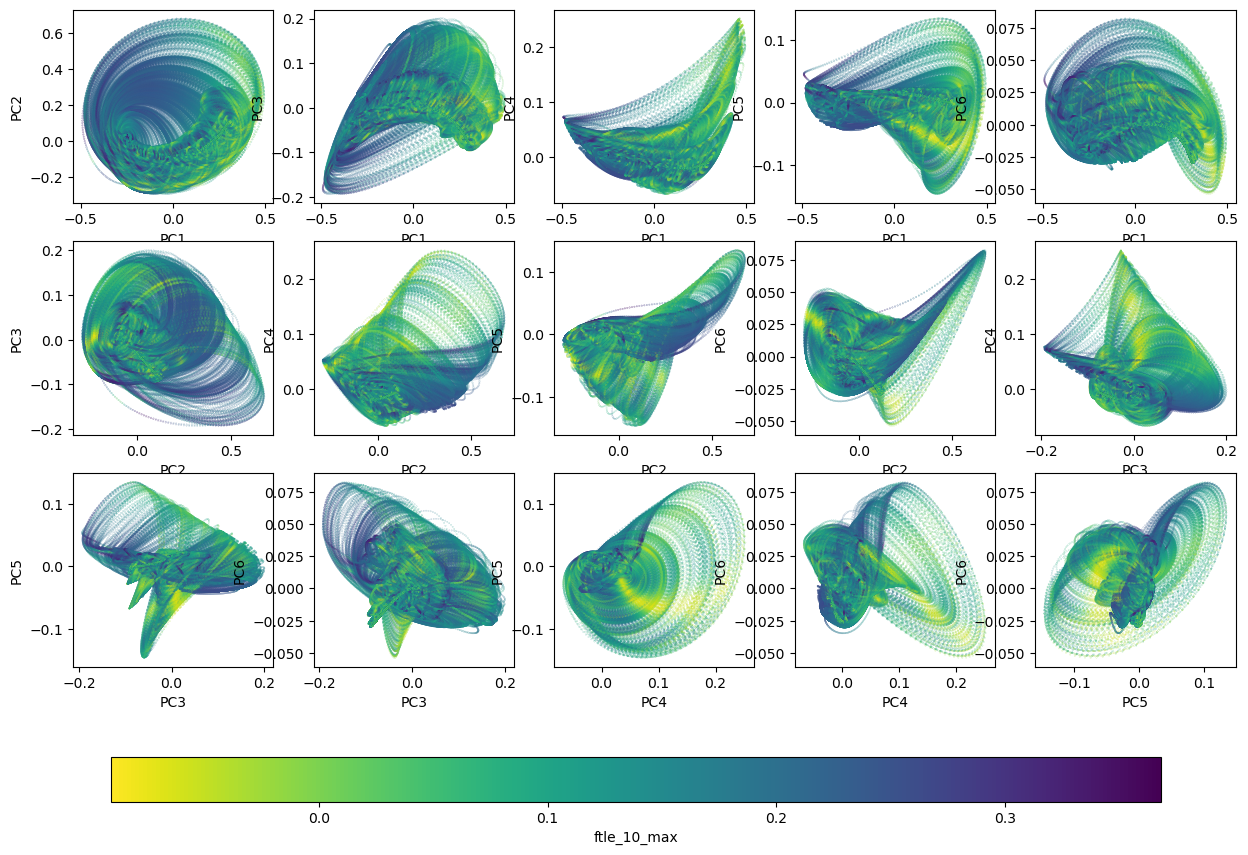

In [70]:
scores_df["ftle_10_max"] = np.max(ftle_dict[10], axis=1)
figs, axes = plot_scatter(scores_df, "ftle_10_max")

### Now do the same with the SVD of the Jacobian

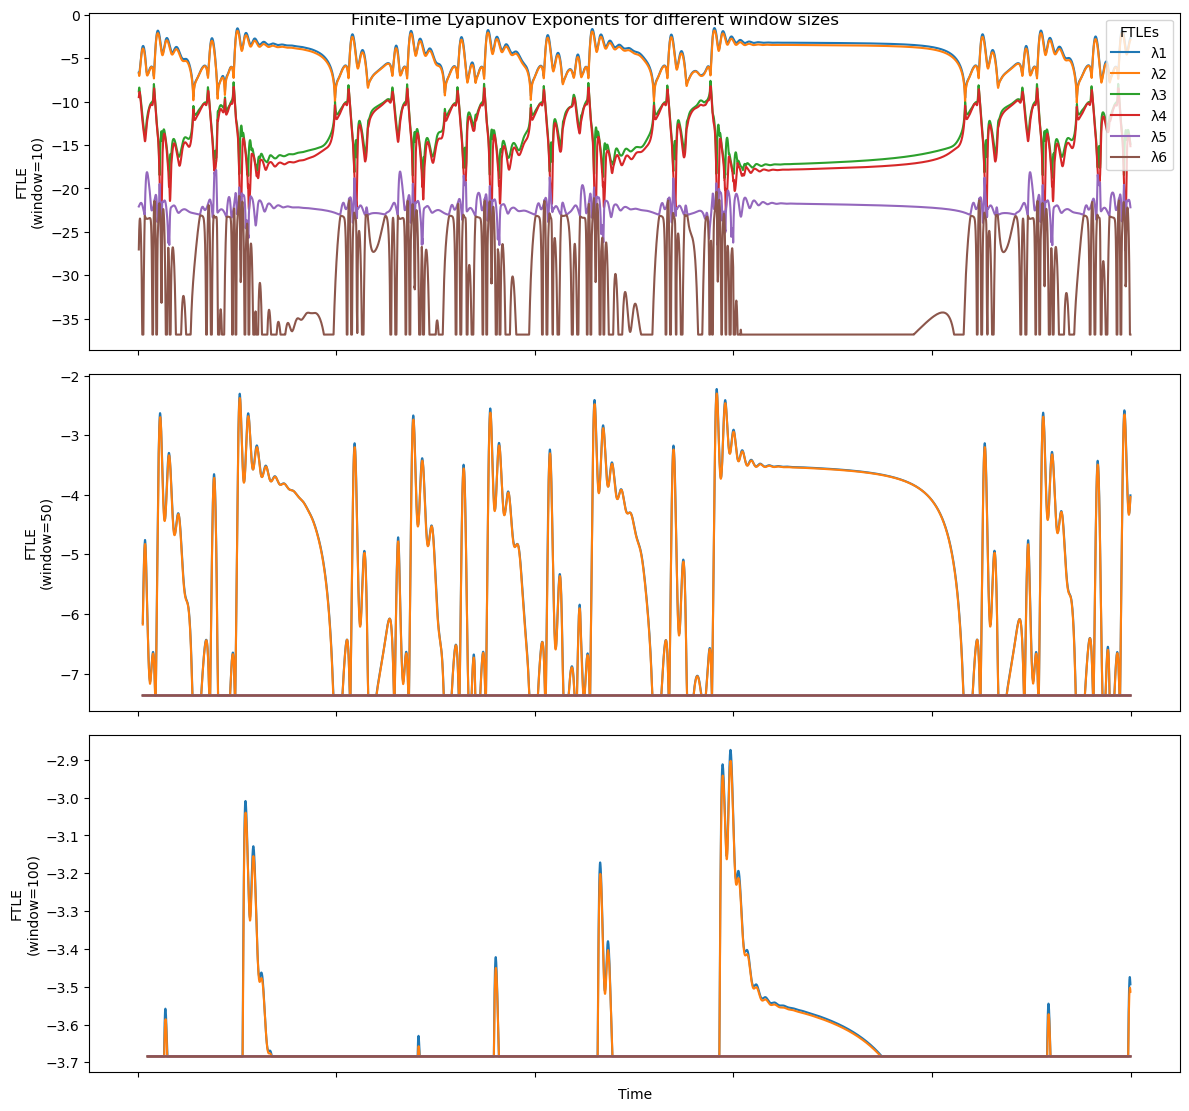

In [55]:
t_max = int(1e4)
window_sizes = [10, 50, 100]
ftle_dict = {w: compute_windowed_ftle(
    traj[:t_max], cdvjac, dt, window=w) for w in window_sizes}
colors = [f'C{j}' for j in range(LEs.shape[0])]

fig, axes = plt.subplots(len(window_sizes), 1, figsize=(12, 12), sharex=True)

for idx, w in enumerate(window_sizes):
    ax = axes[idx]
    _, ftle = ftle_dict[w]
    for j in range(ftle.shape[1]):
        label = f'λ{j+1}' if idx == 0 else None
        ax.plot(times[:t_max], ftle[:t_max, j],
                color=colors[j], linestyle='-', label=label)
    ax.set_ylabel(f"FTLE\n(window={w})")
    if idx == 0:
        ax.legend(loc='upper right', title='FTLEs')
    if idx < len(window_sizes) - 1:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time")

fig.suptitle(
    "Finite-Time Lyapunov Exponents for different window sizes", y=0.92)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [85]:
df = build_df(traj, dims)
results = compute_eof(df, n_modes=6)
scores_df = results['scores_df']
_, ftle = compute_windowed_ftle(
    traj, cdvjac, dt, window=2)
scores_df["ftle_1_max"] = np.max(ftle, axis=1)

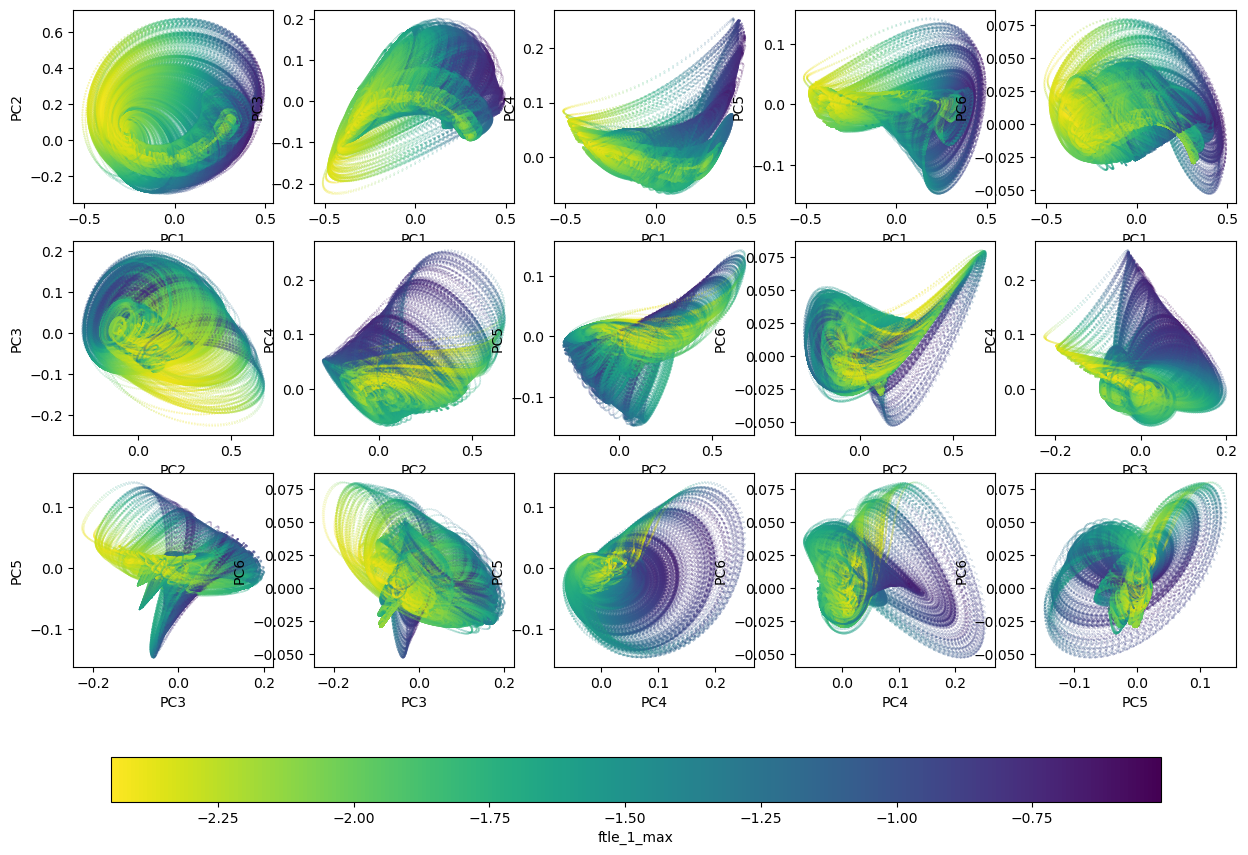

In [86]:
figs, axes = plot_scatter(scores_df, "ftle_1_max")

# Compare HMM state with maximum FTLE

In [64]:
fixed = np.array([
    [0.7285286,   0.15657308, -0.36810966, -0.32854071, -0.08004622, 0.34314342],
    [0.94484848, 0.10714876, -0.00858286, -0.71094887, -0.17206714, 0.03996197]
])
inits = np.r_[fixed, [(fixed[0] + fixed[1]) / 2]]
state_centers, states_sd, states = fit_hmm(
    traj, 3, initial_centers=inits)

Transition Matrix:
Shape: (3, 3)
State 1: [0.9931 0.0050 0.0019]
State 2: [0.0070 0.9930 0.0000]
State 3: [0.0002 0.0022 0.9976]



In [73]:
def compute_episode_ftles(regime_vec, trajectory, jac, dt):
    """
    Segment a trajectory into episodes based on regime_vec (integers).
    For each contiguous episode (same regime), compute:
      - regime id
      - number of steps (length)
      - product of Jacobians over the episode
      - singular values of that product
      - FTLEs = (1/(length*dt)) * ln(singular values)

    Returns a list of dicts:
      [{ 'regime': int,
         'length': int,
         'ftle': np.ndarray
       }, ...]
    """
    n_steps, dim = trajectory.shape
    episodes = []
    # Precompute Jacobians once
    J_list = [jac(trajectory[n], n * dt) for n in range(n_steps)]

    start = 0
    current_regime = regime_vec[0]
    for n in range(1, n_steps):
        if regime_vec[n] != current_regime:
            end = n
            length = end - start
            P = np.eye(dim)
            for k in range(start, end):
                P = J_list[k] @ P
            ftle_vals = ftle_from_jacobian_at_point(P, dt=length * dt)
            episodes.append({
                'regime': current_regime,
                'length': length,
                'ftle': ftle_vals
            })
            start = n
            current_regime = regime_vec[n]
    # handle last episode
    if start < n_steps:
        end = n_steps
        length = end - start
        P = np.eye(dim)
        for k in range(start, end):
            P = J_list[k] @ P
        ftle_vals = ftle_from_jacobian_at_point(P, dt=length * dt)
        episodes.append({
            'regime': current_regime,
            'length': length,
            'ftle': ftle_vals
        })
    return episodes

In [79]:
episodes = compute_episode_ftles(states[:100000], traj[:100000], cdvjac, dt)

In [82]:
def plot_largest_ftle_violin(episodes):
    """
    Create a violin plot of the largest FTLE per regime using Seaborn style.

    Parameters:
    - episodes: list of dicts as returned by compute_episode_ftles,
      each containing 'regime' and 'ftle' (array of FTLEs).

    Returns:
      fig, ax of the violin plot.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Build DataFrame for Seaborn
    records = []
    for ep in episodes:
        reg = ep['regime']
        max_ftle = np.max(ep['ftle'])
        records.append({'FTLE': max_ftle, 'Regime': f'Regime {reg}'})
    df = pd.DataFrame(records)

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.violinplot(
        data=df,
        x='FTLE',
        y='Regime',
        ax=ax,
        inner='box',
        linewidth=1.2
    )
    ax.set_xlabel('Largest FTLE')
    ax.set_ylabel('Regime')
    ax.set_title('Distribution of Largest FTLE by Regime')
    plt.tight_layout()
    return fig, ax

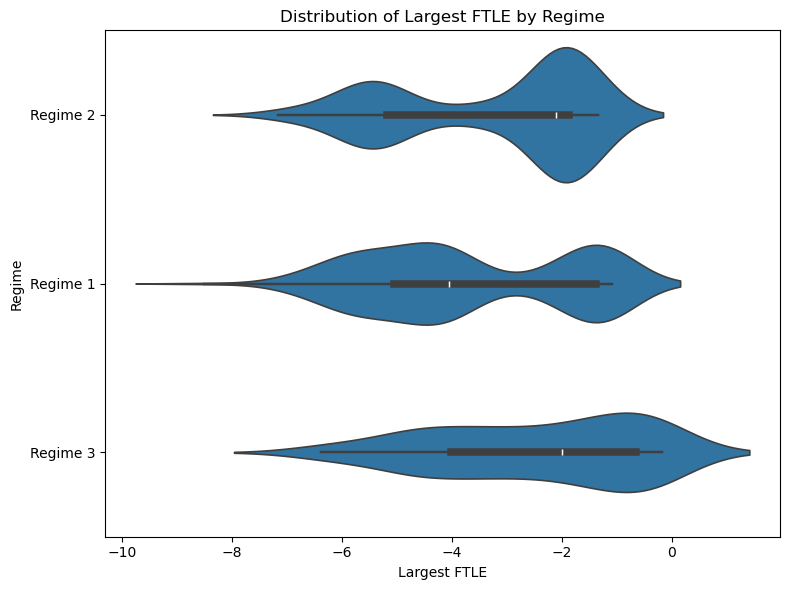

In [83]:
fig, ax = plot_largest_ftle_violin(episodes)
plt.show()

Escape Time Statistics:
 state  n_episodes  mean_escape_time  median_escape_time  std_escape_time  min_escape_time  max_escape_time  total_time_in_state
     2        2461        142.904104               176.0        79.600433             11.0            326.0             351687.0
     1        2515        145.927634                91.0       103.615659             12.0            342.0             367008.0
     3         686        410.067055               137.5       524.520902              8.0           2154.0             281306.0

Regime 2 Analysis:
Number of episodes: 2461
Mean escape time: 142.904
Median escape time: 176.000
Std escape time: 79.600

Points in regime 2: 351687
Escape times range: 1.000 to 326.000

Regime 1 Analysis:
Number of episodes: 2515
Mean escape time: 145.928
Median escape time: 91.000
Std escape time: 103.616

Points in regime 1: 367008
Escape times range: 1.000 to 342.000

Regime 3 Analysis:
Number of episodes: 686
Mean escape time: 410.067
Median escape 

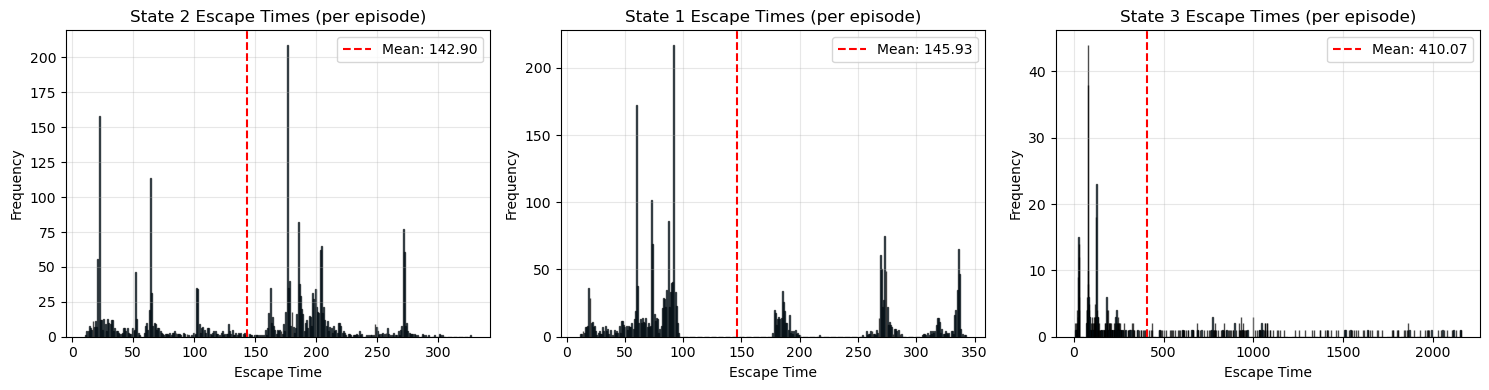

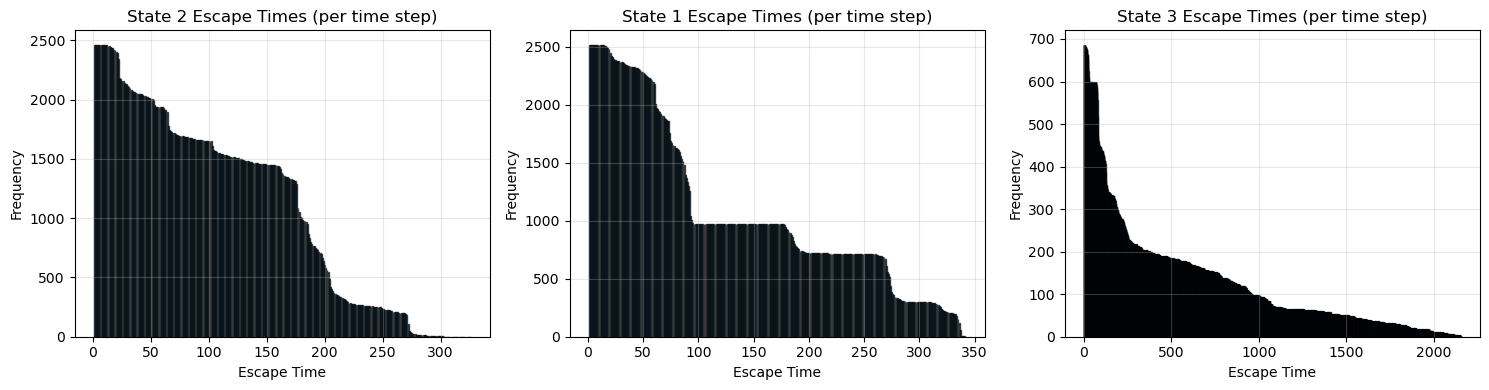

In [65]:
results = analyze_regime_escape_times(states, dt=1.0)

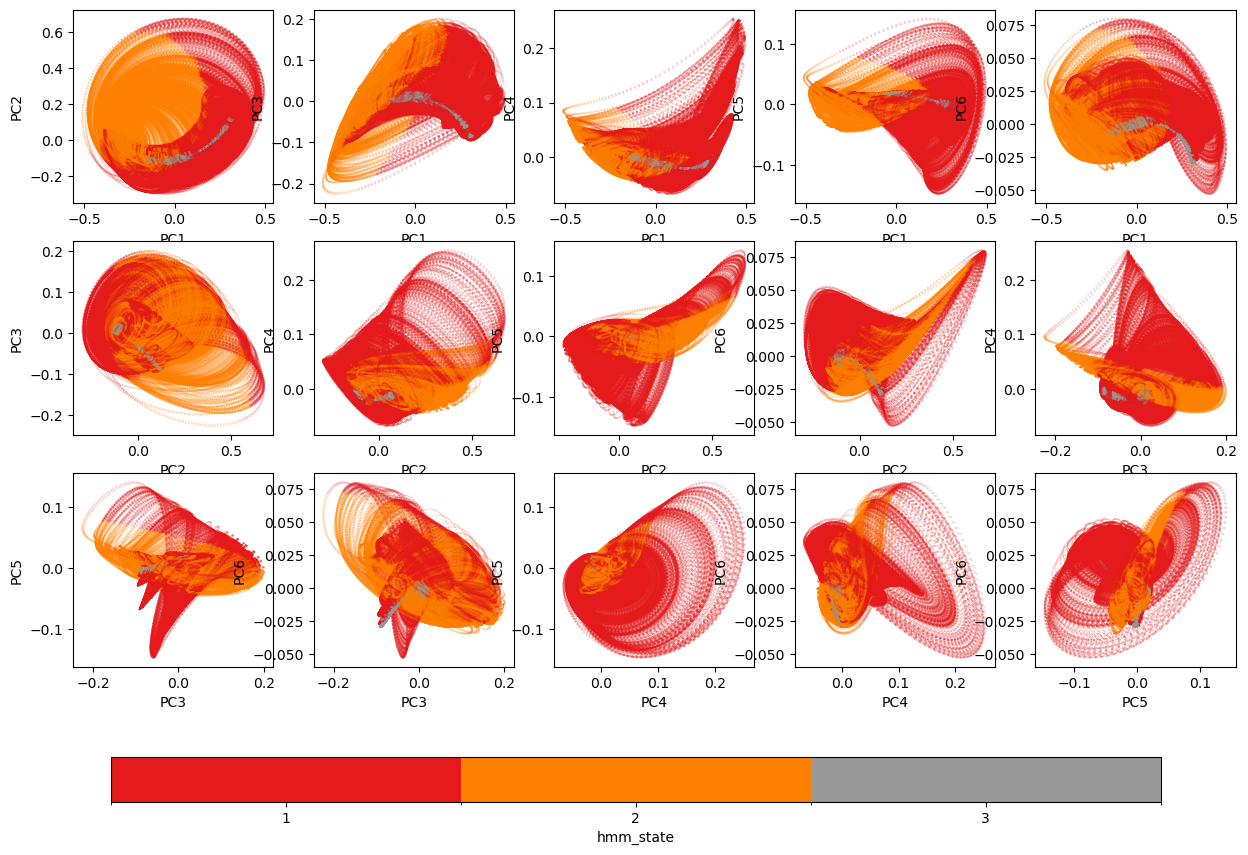

In [84]:
scores_df["hmm_state"] = states
figs, axes = plot_scatter(scores_df, "hmm_state",
                          cmap="Set1", categorical=True)

In [6]:
import pickle

# List of variable names that took long to generate
long_vars = [
    'state_LCE', 'history', 'CdV_LCE', 'logs', 'ftle_dict',
    'state_centers', 'states_sd', 'states'
]

In [ ]:


# Save each variable to a separate pickle file
for var in long_vars:
    with open(f"FTLE_{var}.pkl", "wb") as f:
        pickle.dump(globals()[var], f)

In [7]:

# Dictionary to hold loaded variables
loaded_data = {}

# Load each variable
for var in long_vars:
    with open(f"FTLE_{var}.pkl", "rb") as f:
        loaded_data[var] = pickle.load(f)

ftle_dict = loaded_data['ftle_dict']
states = loaded_data['states']
window_sizes = [10, 50, 100, 500, 1000]

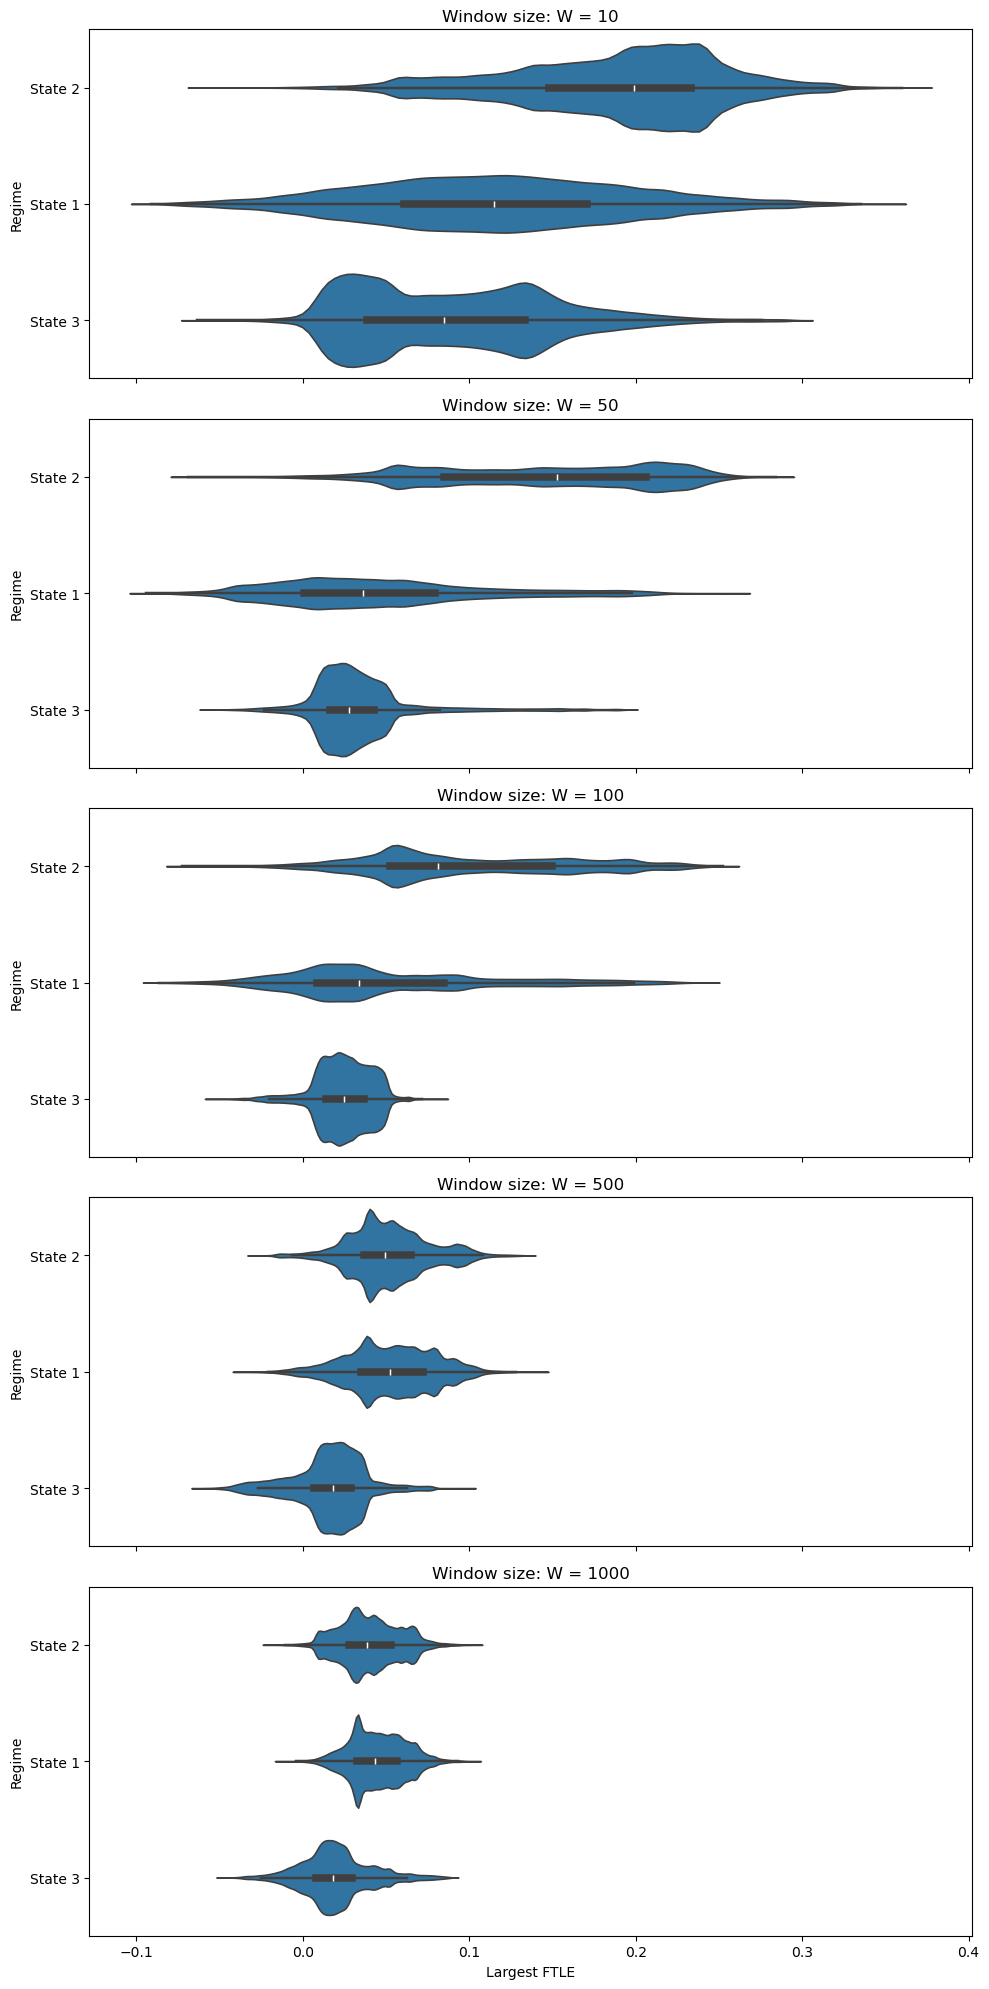

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Compute max FTLE per window
max_ftle = {
    w: np.max(arr, axis=1)
    for w, arr in ftle_dict.items()
}

# 2) Reshape into long-form DataFrame for Seaborn
records = []
for w, ftle_vals in max_ftle.items():
    for val, state in zip(ftle_vals, states):
        records.append({
            'FTLE': val,
            'Regime': f'State {state}',
            'Window': f'W = {w}'
        })

df = pd.DataFrame(records)

# 3) Set up subplots: one violin plot per window size
unique_windows = df['Window'].unique()
fig, axes = plt.subplots(
    nrows=len(unique_windows),
    ncols=1,
    figsize=(10, 4 * len(unique_windows)),
    sharex=True
)

# 4) Plot violin plots
for ax, window in zip(axes, unique_windows):
    sns.violinplot(
        data=df[df['Window'] == window],
        x='FTLE',
        y='Regime',
        ax=ax,
        inner='box',       # show median, IQR, and whiskers
        linewidth=1.2
    )
    ax.set_title(f"Window size: {window}")
    ax.set_ylabel("Regime")

# 5) Final touches
axes[-1].set_xlabel("Largest FTLE")
fig.tight_layout()
plt.show()